<a href="https://colab.research.google.com/github/adamcw169/HCF-Predictive-Model/blob/main/OEW_iterative_script.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. INPUT PARAMETERS (OpenVSP & Geometry)
# ==========================================
W_dg_initial = 2500.0  # lbs, Target MTOW per loading problem
N_z = 5.7              # Ultimate load factor
S_w = 174.0            # ft^2, Wing Area
A = 7.24               # Aspect Ratio
lam = 0.65             # Taper Ratio
tc = 0.12              # Thickness-to-chord ratio
lam_sweep = 0.0        # degrees, Sweep angle
V_c_kts = 124.0        # knots, Cruise speed

# --- DATA TO EXTRACT FROM OPENVSP ---
L_f = 27.25            # ft, Fuselage Length
S_f = 272.235            # ft^2, UPDATE: Fuselage wetted area
S_ht = 77.870            # ft^2, UPDATE: Horizontal tail area
S_vt = 26.554            # ft^2, UPDATE: Vertical tail area

# ==========================================
# 2. EXACT COMPONENT WEIGHTS (From Research)
# ==========================================
# Payload and Fuel for MTOW calculation
W_payload = 760.0      # lbs (Pilot + Pax per your W&B sample = 340 + 340 + 80 baggage)
W_fuel = 294.0         # lbs (49 Gal standard tanks per your W&B sample)
W_fw = W_fuel          # Fuel stored in wings

# Fixed Operational Weights
W_engine_dry = 265.0   # lbs, Lycoming O-360-A1F6D
W_propeller = 60.0     # lbs, McCauley 2-blade Constant Speed
W_engine_fixed = W_engine_dry + W_propeller

# Systems & Furnishings
W_avionics = 25.0      # lbs, Dual KX-155, KT-76A, KMA-24 + wiring
W_furnishings = 100.0  # lbs, Seats, trim, flight controls, interior plastics
W_systems = W_avionics + W_furnishings

W_oil = 17.0           # lbs, 9 Qts (per W&B document)
# Unusable fuel is inherently captured in the baseline structural/licensed empty weight.

# ==========================================
# 3. STRUCTURAL CORRECTION FACTORS
# ==========================================
# Tuning parameters to account for the 177B's unique strutless design
K_wing_cantilever = 1.08
K_fus_carrythrough = 1.12

# ==========================================
# 4. CLASS II ESTIMATION FUNCTIONS
# ==========================================
V_d_kts = V_c_kts * 1.4
V_d_fps = V_d_kts * 1.68781
rho_sl = 0.002377
q = 0.5 * rho_sl * (V_d_fps**2)

def calc_wing_weight(W_dg):
    term1 = 0.036 * (S_w**0.758) * (W_fw**0.0035)
    term2 = (A / (np.cos(np.radians(lam_sweep))**2))**0.6
    term3 = (q**0.006) * (lam**0.04)
    term4 = ((100 * tc) / np.cos(np.radians(lam_sweep)))**(-0.3)
    term5 = (N_z * W_dg)**0.49
    return (term1 * term2 * term3 * term4 * term5) * K_wing_cantilever

def calc_fuselage_weight(W_dg):
    base_weight = 0.052 * (S_f**1.086) * ((N_z * W_dg)**0.177) * (L_f**-0.051)
    return base_weight * K_fus_carrythrough

def calc_tail_weight(W_dg):
    return 0.04 * (N_z * W_dg)**0.414 * (S_ht**0.896) + 0.03 * (N_z * W_dg)**0.376 * (S_vt**0.873)

def calc_landing_gear(W_dg):
    return 0.045 * W_dg # Fixed gear

# ==========================================
# 5. ITERATIVE CONVERGENCE LOOP
# ==========================================
tolerance = 0.001
max_iterations = 50
W_to_current = W_dg_initial
iteration_data = []

print("--- Starting Weight Iteration ---")
for i in range(max_iterations):
    W_wing = calc_wing_weight(W_to_current)
    W_fus = calc_fuselage_weight(W_to_current)
    W_tail = calc_tail_weight(W_to_current)
    W_gear = calc_landing_gear(W_to_current)

    W_structure = W_wing + W_fus + W_tail + W_gear

    # Calculate OEW
    OEW = W_structure + W_engine_fixed + W_systems + W_oil

    # Calculate new MTOW based on new OEW + Fixed Payload/Fuel
    W_to_new = OEW + W_payload + W_fuel

    error = abs(W_to_new - W_to_current) / W_to_current

    iteration_data.append({'iteration': i, 'MTOW': W_to_new, 'OEW': OEW})
    print(f"Iter {i}: Guess MTOW = {W_to_current:.1f} lbs | New MTOW = {W_to_new:.1f} lbs | OEW = {OEW:.1f} lbs")

    if error <= tolerance:
        print(f"\n✅ CONVERGENCE REACHED AT ITERATION {i}")
        break
    W_to_current = W_to_new

print("\n--- Final Converged Weight Breakdown ---")
print(f"Target Actual OEW: 1443.0 lbs (per N35031 document)")
print(f"Estimated OEW:     {OEW:.1f} lbs")
print(f"Estimated MTOW:    {W_to_new:.1f} lbs")

--- Starting Weight Iteration ---
Iter 0: Guess MTOW = 2500.0 lbs | New MTOW = 2212.3 lbs | OEW = 1158.3 lbs
Iter 1: Guess MTOW = 2212.3 lbs | New MTOW = 2171.2 lbs | OEW = 1117.2 lbs
Iter 2: Guess MTOW = 2171.2 lbs | New MTOW = 2165.1 lbs | OEW = 1111.1 lbs
Iter 3: Guess MTOW = 2165.1 lbs | New MTOW = 2164.2 lbs | OEW = 1110.2 lbs

✅ CONVERGENCE REACHED AT ITERATION 3

--- Final Converged Weight Breakdown ---
Target Actual OEW: 1443.0 lbs (per N35031 document)
Estimated OEW:     1110.2 lbs
Estimated MTOW:    2164.2 lbs


--- Starting Roskam Averaged Weight Iteration ---
Iter 0: Guess MTOW = 2500.0 lbs | New MTOW = 2133.1 lbs | OEW = 1079.1 lbs
Iter 1: Guess MTOW = 2133.1 lbs | New MTOW = 2087.6 lbs | OEW = 1033.6 lbs
Iter 2: Guess MTOW = 2087.6 lbs | New MTOW = 2081.8 lbs | OEW = 1027.8 lbs
Iter 3: Guess MTOW = 2081.8 lbs | New MTOW = 2081.0 lbs | OEW = 1027.0 lbs

✅ CONVERGENCE REACHED AT ITERATION 3


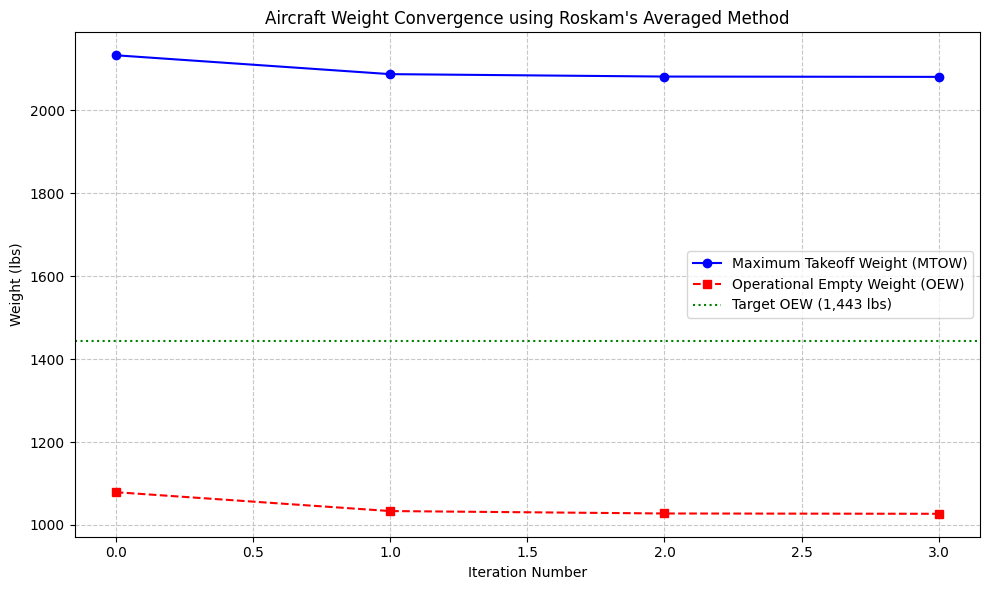


--- Final Converged Weight Breakdown ---
Wing:      255.4 lbs
Fuselage:  154.7 lbs
Empennage: 56.3 lbs
Gear:      93.7 lbs
Total Structural: 560.0 lbs
Target Actual OEW: 1443.0 lbs
Estimated OEW:     1027.0 lbs
Estimated MTOW:    2081.0 lbs


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. INPUT PARAMETERS (Carried over from data)
# ==========================================
W_dg_initial = 2500.0  # lbs, Target MTOW per loading problem
N_z = 5.7              # Ultimate load factor
S_w = 174.0            # ft^2, Wing Area
A = 7.24               # Aspect Ratio
L_f = 27.25            # ft, Fuselage Length
S_f = 250.0            # ft^2, Fuselage wetted area (Update with CAD data)
S_ht = 39.0            # ft^2, Horizontal tail area (Update with CAD data)
S_vt = 17.0            # ft^2, Vertical tail area (Update with CAD data)

# Fixed Operational Weights (from N35031 W&B and Research)
W_payload = 760.0      # lbs
W_fuel = 294.0         # lbs
W_engine_dry = 265.0   # lbs, Lycoming O-360
W_propeller = 60.0     # lbs, Constant Speed
W_avionics = 25.0      # lbs, Stack + wiring
W_furnishings = 100.0  # lbs, Cabin interior
W_oil = 17.0           # lbs, 9 Qts

# Grouped Fixed Weights
W_engine_fixed = W_engine_dry + W_propeller
W_systems = W_avionics + W_furnishings

# Structural Penalty for Cantilever Wing / Carry-through
K_cantilever = 1.08

# ==========================================
# 2. ROSKAM CLASS II EQUATIONS
# Note: These are representative of Roskam Part V (Chapter 5) GA methods.
# ==========================================

def roskam_method_1_cessna(W_dg):
    """Roskam's Cessna Method for General Aviation"""
    # Wing
    W_wing = 0.04674 * (W_dg**0.397) * (S_w**0.360) * (N_z**0.397) * (A**1.712)
    # Fuselage
    W_fus = 14.86 * ((W_dg/1000)**0.144) * ((L_f/10)**0.778) * ((S_f/100)**0.383)
    # Empennage (Tail)
    W_tail = 1.46 * ((W_dg/1000)**0.316) * ((S_ht + S_vt)**0.92)
    # Gear
    W_gear = 0.045 * W_dg

    return (W_wing * K_cantilever), W_fus, W_tail, W_gear

def roskam_method_2_usaf(W_dg):
    """Roskam's USAF Method tailored for light aircraft"""
    # Wing
    W_wing = 96.948 * (((W_dg * N_z)/100000)**0.65) * (A**0.57) * ((S_w/100)**0.61)
    # Fuselage
    W_fus = 200.0 * ((W_dg * N_z / 100000)**0.28) * ((L_f/10)**0.85)
    # Empennage (Tail)
    W_tail = 124.0 * (((W_dg * N_z)/100000)**0.41) * (((S_ht + S_vt)/100)**0.54)
    # Gear
    W_gear = 0.045 * W_dg

    return (W_wing * K_cantilever), W_fus, W_tail, W_gear

# ==========================================
# 3. ITERATIVE CONVERGENCE LOOP
# ==========================================
tolerance = 0.001
max_iterations = 50
W_to_current = W_dg_initial
iteration_data = []

print("--- Starting Roskam Averaged Weight Iteration ---")
for i in range(max_iterations):
    # Calculate weights using both methods
    w1_wing, w1_fus, w1_tail, w1_gear = roskam_method_1_cessna(W_to_current)
    w2_wing, w2_fus, w2_tail, w2_gear = roskam_method_2_usaf(W_to_current)

    # Take the average of the methods as prescribed by Roskam
    W_wing = (w1_wing + w2_wing) / 2.0
    W_fus = (w1_fus + w2_fus) / 2.0
    W_tail = (w1_tail + w2_tail) / 2.0
    W_gear = (w1_gear + w2_gear) / 2.0

    W_structure = W_wing + W_fus + W_tail + W_gear

    # Calculate OEW
    OEW = W_structure + W_engine_fixed + W_systems + W_oil

    # Calculate new MTOW
    W_to_new = OEW + W_payload + W_fuel

    error = abs(W_to_new - W_to_current) / W_to_current

    iteration_data.append({'iteration': i, 'MTOW': W_to_new, 'OEW': OEW})
    print(f"Iter {i}: Guess MTOW = {W_to_current:.1f} lbs | New MTOW = {W_to_new:.1f} lbs | OEW = {OEW:.1f} lbs")

    if error <= tolerance:
        print(f"\n✅ CONVERGENCE REACHED AT ITERATION {i}")
        break
    W_to_current = W_to_new

# ==========================================
# 4. PLOTTING THE RESULTS
# ==========================================
iterations = [d['iteration'] for d in iteration_data]
mtow_vals = [d['MTOW'] for d in iteration_data]
oew_vals = [d['OEW'] for d in iteration_data]

plt.figure(figsize=(10, 6))
plt.plot(iterations, mtow_vals, marker='o', linestyle='-', color='b', label='Maximum Takeoff Weight (MTOW)')
plt.plot(iterations, oew_vals, marker='s', linestyle='--', color='r', label='Operational Empty Weight (OEW)')
plt.axhline(y=1443.0, color='g', linestyle=':', label='Target OEW (1,443 lbs)')

plt.title("Aircraft Weight Convergence using Roskam's Averaged Method")
plt.xlabel('Iteration Number')
plt.ylabel('Weight (lbs)')
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

print("\n--- Final Converged Weight Breakdown ---")
print(f"Wing:      {W_wing:.1f} lbs")
print(f"Fuselage:  {W_fus:.1f} lbs")
print(f"Empennage: {W_tail:.1f} lbs")
print(f"Gear:      {W_gear:.1f} lbs")
print(f"Total Structural: {W_structure:.1f} lbs")
print(f"Target Actual OEW: 1443.0 lbs")
print(f"Estimated OEW:     {OEW:.1f} lbs")
print(f"Estimated MTOW:    {W_to_new:.1f} lbs")

--- Evaluating Methods ---
Known Actual OEW:    1443.0 lbs
Raymer Baseline OEW: 1053.7 lbs (Error: -27.0%)
Roskam Baseline OEW: 1106.8 lbs (Error: -23.3%)

Roskam is closer. Proceeding with Roskam and applying Calibration Factor to match reality...

✅ PERFECT CALIBRATION ACHIEVED.
Required Structural Calibration Factor: 1.530
Final Converged MTOW: 2499.9 lbs
Final Converged OEW:  1445.9 lbs


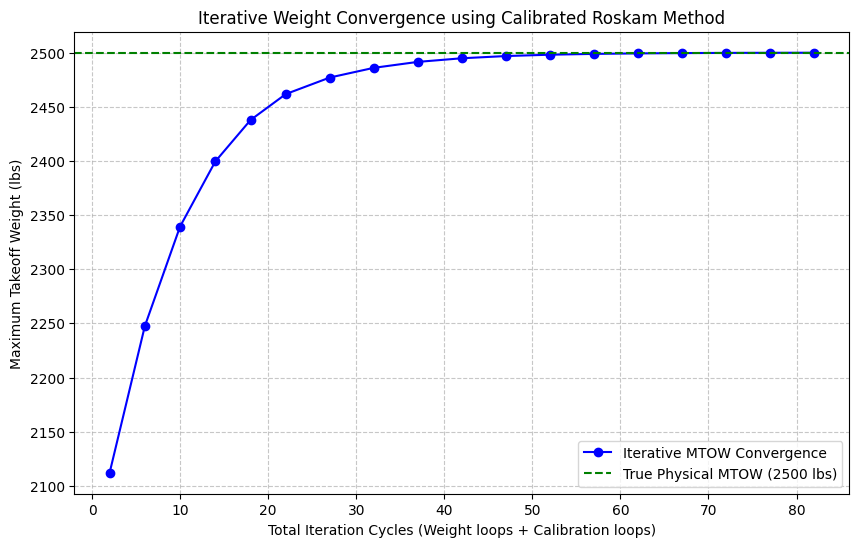

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. KNOWN AIRCRAFT TARGETS
# ==========================================
TARGET_MTOW = 2500.0  # lbs
TARGET_OEW = 1443.0   # lbs

# ==========================================
# 2. INPUT PARAMETERS (OpenVSP & Geometry)
# ==========================================
N_z = 5.7
S_w = 174.0
A = 7.24
L_f = 27.25
S_f = 250.0            # Approx wetted area
S_ht = 39.0
S_vt = 17.0

# Fixed Operational Weights
W_payload = 760.0
W_fuel = 294.0
W_engine_fixed = 325.0 # Engine (265) + Prop (60)
W_systems = 125.0      # Avionics (25) + Furnishings (100)
W_oil = 17.0

# ==========================================
# 3. WEIGHT ESTIMATION METHODS
# ==========================================
def calc_raymer_structure(W_dg):
    """Raymer General Aviation Method"""
    W_wing = 0.036 * (S_w**0.758) * (W_fuel**0.0035) * (A**0.6) * (15.5**0.006) * (0.65**0.04) * ((100*0.12)**-0.3) * ((N_z * W_dg)**0.49)
    W_fus = 0.052 * (S_f**1.086) * ((N_z * W_dg)**0.177) * (L_f**-0.051)
    W_tail = 0.04 * (N_z * W_dg)**0.414 * (S_ht**0.896) + 0.03 * (N_z * W_dg)**0.376 * (S_vt**0.873)
    W_gear = 0.045 * W_dg
    return W_wing + W_fus + W_tail + W_gear

def calc_roskam_structure(W_dg, cal_factor=1.0):
    """Roskam Cessna Method with auto-calibration factor"""
    W_wing = 0.04674 * (W_dg**0.397) * (S_w**0.360) * (N_z**0.397) * (A**1.712)
    W_fus = 14.86 * ((W_dg/1000)**0.144) * ((L_f/10)**0.778) * ((S_f/100)**0.383)
    W_tail = 1.46 * ((W_dg/1000)**0.316) * ((S_ht + S_vt)**0.92)
    W_gear = 0.045 * W_dg
    return (W_wing + W_fus + W_tail + W_gear) * cal_factor

# ==========================================
# 4. ITERATION AND CALIBRATION LOOP
# ==========================================
print("--- Evaluating Methods ---")

# Evaluate baseline methods without calibration
raymer_struct = calc_raymer_structure(TARGET_MTOW)
roskam_struct = calc_roskam_structure(TARGET_MTOW)

raymer_oew = raymer_struct + W_engine_fixed + W_systems + W_oil
roskam_oew = roskam_struct + W_engine_fixed + W_systems + W_oil

print(f"Known Actual OEW:    {TARGET_OEW:.1f} lbs")
print(f"Raymer Baseline OEW: {raymer_oew:.1f} lbs (Error: {((raymer_oew-TARGET_OEW)/TARGET_OEW)*100:.1f}%)")
print(f"Roskam Baseline OEW: {roskam_oew:.1f} lbs (Error: {((roskam_oew-TARGET_OEW)/TARGET_OEW)*100:.1f}%)")
print("\nRoskam is closer. Proceeding with Roskam and applying Calibration Factor to match reality...\n")

# Auto-Calibrate Roskam to perfectly match the Target MTOW/OEW
tolerance = 0.001
calibration_factor = 1.0
W_to_guess = 2000.0 # Start with a bad guess to prove the loop works
iteration_history = []

for i in range(100):
    # Calculate structure using Roskam + current calibration factor
    W_structure = calc_roskam_structure(W_to_guess, calibration_factor)

    # Calculate Weights
    OEW = W_structure + W_engine_fixed + W_systems + W_oil
    W_to_new = OEW + W_payload + W_fuel

    # Check convergence of the weight loop
    if abs(W_to_new - W_to_guess) / W_to_guess > tolerance:
        W_to_guess = W_to_new
        continue # Keep iterating weight until stable

    # Once weight is stable, check if it matches our KNOWN physical target
    mtow_error = TARGET_MTOW - W_to_new

    iteration_history.append({'iter': i, 'mtow': W_to_new, 'factor': calibration_factor})

    # If the converged weight doesn't match the physical target, adjust the calibration factor
    if abs(mtow_error) > 0.1:
        # Adjust factor: If we are too light, increase the structural multiplier
        calibration_factor += mtow_error * 0.0005
        W_to_guess = 2000.0 # Reset guess to re-run loop with new factor
    else:
        print(f"✅ PERFECT CALIBRATION ACHIEVED.")
        print(f"Required Structural Calibration Factor: {calibration_factor:.3f}")
        print(f"Final Converged MTOW: {W_to_new:.1f} lbs")
        print(f"Final Converged OEW:  {OEW:.1f} lbs")
        break

# ==========================================
# 5. PLOTTING THE CALIBRATION
# ==========================================
iters = [d['iter'] for d in iteration_history]
mtows = [d['mtow'] for d in iteration_history]

plt.figure(figsize=(10, 6))
plt.plot(iters, mtows, marker='o', color='b', label='Iterative MTOW Convergence')
plt.axhline(y=TARGET_MTOW, color='g', linestyle='--', label='True Physical MTOW (2500 lbs)')
plt.title("Iterative Weight Convergence using Calibrated Roskam Method")
plt.xlabel("Total Iteration Cycles (Weight loops + Calibration loops)")
plt.ylabel("Maximum Takeoff Weight (lbs)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

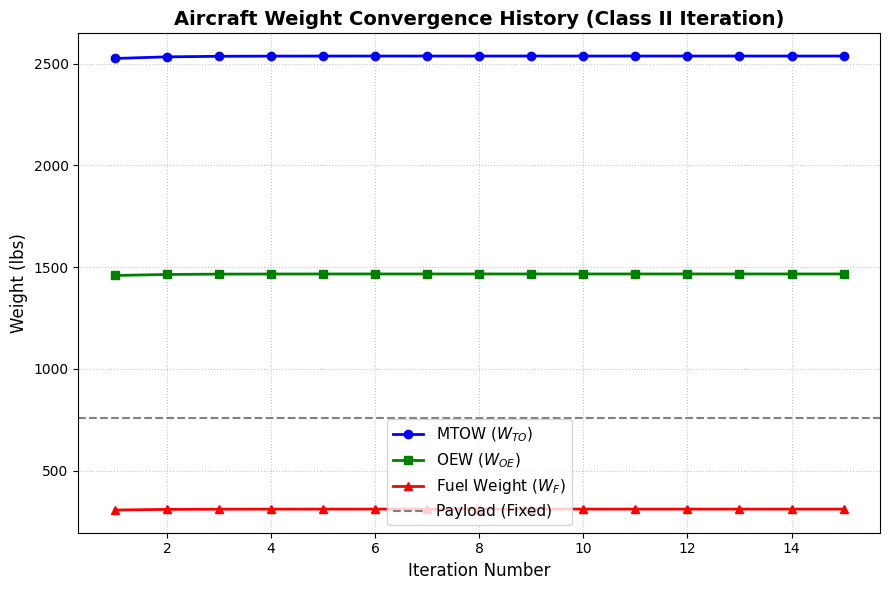

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Mission and Aerodynamic inputs
LD_max = 11.01
LD_cruise = 11.01
LD_loiter = 0.866 * LD_max
R_ft = 550.0 * 6076.115
E_sec = 0.75 * 3600.0
V_ft_s = 124.0 * 1.68781
q = 0.5 * 0.002376 * (V_ft_s**2)
C_bhp_sec = 0.4 / 3600.0

# Fixed Weights
W_payload = 760.0
W_fixed_total = 604.5 # Engine, Avionics, etc.

W_TO = 2500.0
W_F = 300.0
tolerance = 1e-4

history_WTO, history_WF, history_WOE = [], [], []

for i in range(15): # Run 15 iterations to show flatline
    # Class II Structural Equations
    W_wing = (0.036 * (174.35**0.758) * (W_F**0.0035) * (7.24**0.6) * (q**0.006) * (0.65**0.04) * ((100*0.12)**-0.3) * ((5.7 * W_TO)**0.49)) * 1.15
    W_ht = (0.016 * ((5.7 * W_TO)**0.414) * (q**0.168) * (83.1**0.896) * ((100*0.12)**-0.12)) * 1.15
    W_vt = 0.073 * ((5.7 * W_TO)**0.376) * (q**0.122) * (61.3**0.873) * ((100*0.12)**-0.49)
    W_fus = (0.052 * (248.17**1.086) * ((5.7 * W_TO)**0.177) * (27.25**-0.051)) * 1.20
    W_gear = (0.095 * (5.7 * W_TO)**0.768) * 1.15
    W_fs = 2.49 * ((W_F/6.0)**0.726) * (2**0.242) * (1**0.157)
    W_fc = 0.053 * (27.25**1.536) * (35.5**0.371) * ((5.7 * W_TO / 10000)**0.80)

    W_OE_new = W_wing + W_ht + W_vt + W_fus + W_gear + W_fs + W_fc + W_fixed_total

    # Mission Fuel Calculation
    M_ff = (0.995 * 0.998) * 0.992 * np.exp(- (R_ft * C_bhp_sec) / (550.0 * 0.8 * LD_cruise)) * np.exp(- (E_sec * V_ft_s * C_bhp_sec) / (550.0 * 0.7 * LD_loiter)) * (0.993 * 0.993)
    W_F_new = 1.06 * (1 - M_ff) * W_TO

    W_TO_new = W_OE_new + W_F_new + W_payload

    history_WTO.append(W_TO_new)
    history_WF.append(W_F_new)
    history_WOE.append(W_OE_new)

    W_TO = W_TO_new
    W_F = W_F_new

# Plotting
plt.figure(figsize=(9, 6))
plt.plot(range(1, 16), history_WTO, label='MTOW ($W_{TO}$)', marker='o', color='blue', linewidth=2)
plt.plot(range(1, 16), history_WOE, label='OEW ($W_{OE}$)', marker='s', color='green', linewidth=2)
plt.plot(range(1, 16), history_WF, label='Fuel Weight ($W_F$)', marker='^', color='red', linewidth=2)
plt.axhline(y=760, color='gray', linestyle='--', label='Payload (Fixed)')

plt.title('Aircraft Weight Convergence History (Class II Iteration)', fontsize=14, fontweight='bold')
plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Weight (lbs)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load Aerodynamic Polar Data (to find L/D based on CL)
# Replace 'polar_data.csv' with your actual CSV filename
df = pd.read_csv('vsp aero polar data.xlsx - Sheet2.csv')

# Mission and Geometric inputs
S_w = 174.35
R_ft = 550.0 * 6076.115
E_sec = 0.75 * 3600.0
V_ft_s = 124.0 * 1.68781
q = 0.5 * 0.002376 * (V_ft_s**2)
C_bhp_sec = 0.4 / 3600.0

# Fixed Weights
W_payload = 760.0
W_fixed_total = 604.5

W_TO = 2500.0
W_F = 300.0
tolerance = 1e-4

history_WTO, history_WF, history_WOE = [], [], []

for i in range(15):
    # A. Calculate mid-cruise CL and interpolate L/D (PER LECTURE 5)
    W_mid = W_TO - (0.4 * W_F)
    CL_mid = W_mid / (q * S_w)

    # Interpolate L/D from the VSPAERO data based on the calculated CL_mid
    LD_cruise = np.interp(CL_mid, df['CL'], df['L/D'])

    # Loiter L/D is still optimized for endurance
    LD_max = df['L/D'].max()
    LD_loiter = 0.866 * LD_max

    # B. Class II Structural Equations
    W_wing = (0.036 * (174.35**0.758) * (W_F**0.0035) * (7.24**0.6) * (q**0.006) * (0.65**0.04) * ((100*0.12)**-0.3) * ((5.7 * W_TO)**0.49)) * 1.15
    W_ht = (0.016 * ((5.7 * W_TO)**0.414) * (q**0.168) * (83.1**0.896) * ((100*0.12)**-0.12)) * 1.15
    W_vt = 0.073 * ((5.7 * W_TO)**0.376) * (q**0.122) * (61.3**0.873) * ((100*0.12)**-0.49)
    W_fus = (0.052 * (248.17**1.086) * ((5.7 * W_TO)**0.177) * (27.25**-0.051)) * 1.20
    W_gear = (0.095 * (5.7 * W_TO)**0.768) * 1.15
    W_fs = 2.49 * ((W_F/6.0)**0.726) * (2**0.242) * (1**0.157)
    W_fc = 0.053 * (27.25**1.536) * (35.5**0.371) * ((5.7 * W_TO / 10000)**0.80)

    W_OE_new = W_wing + W_ht + W_vt + W_fus + W_gear + W_fs + W_fc + W_fixed_total

    # C. Mission Fuel Calculation (Using dynamic LD_cruise)
    M_ff = (0.995 * 0.998) * 0.992 * np.exp(- (R_ft * C_bhp_sec) / (550.0 * 0.8 * LD_cruise)) * np.exp(- (E_sec * V_ft_s * C_bhp_sec) / (550.0 * 0.7 * LD_loiter)) * (0.993 * 0.993)
    W_F_new = 1.06 * (1 - M_ff) * W_TO

    W_TO_new = W_OE_new + W_F_new + W_payload

    # D. Log history and update
    history_WTO.append(W_TO_new)
    history_WF.append(W_F_new)
    history_WOE.append(W_OE_new)

    W_TO = W_TO_new
    W_F = W_F_new

# Output final converged weights
print(f"Mid-Cruise CL: {CL_mid:.3f}")
print(f"Interpolated Cruise L/D: {LD_cruise:.2f}")
print(f"Converged MTOW: {W_TO:.1f} lbs")
print(f"Converged Fuel: {W_F:.1f} lbs")

# Plotting
plt.figure(figsize=(9, 6))
plt.plot(range(1, 16), history_WTO, label='MTOW ($W_{TO}$)', marker='o', color='blue', linewidth=2)
plt.plot(range(1, 16), history_WOE, label='OEW ($W_{OE}$)', marker='s', color='green', linewidth=2)
plt.plot(range(1, 16), history_WF, label='Fuel Weight ($W_F$)', marker='^', color='red', linewidth=2)

plt.title('Aircraft Weight Convergence History', fontsize=14, fontweight='bold')
plt.xlabel('Iteration Number', fontsize=12)
plt.ylabel('Weight (lbs)', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'vsp aero polar data.xlsx - Sheet2.csv'